In [ ]:
# Phase 1: Initial Sanity Check and Logical Pruning (The "Quick Look")
"""Phase 1 done in the data_preprocessing"""

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data set
df = pd.read_csv('../data/HR_Data.csv')

# Find out all columns with unknown values
for col in df.columns:
    print(f"{col}: {df[col].unique()[ :30]}")

print("_"*50)

print(df['WorkLifeBalance'].unique())

# Set some plottting styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Age: [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56]
Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DailyRate: [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705]
Department: ['Sales' 'Research & Development' 'Human Resources']
DistanceFromHome: [ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13]
Education: [2 1 4 3 5]
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
EmployeeCount: [1]
EmployeeNumber: [ 1  2  4  5  7  8 10 11 12 13 14 15 16 18 19 20 21 22 23 24 26 27 28 30
 31 32 33 35 36 38]
EnvironmentSatisfaction: [2 3 4 1]
Gender: ['Female' 'Male']
HourlyRate: [94 61 92 56 40 79 81 67 44 84 49 31 93 50 51 80 96 78 45 82 53 83 58 72
 48 42 41 86 97 75]
JobInvolvement: [3 2 4 1]
JobLevel: [2 1 3 4 5]
JobRol

Attrition        No       Yes
OverTime                     
No         0.895636  0.104364
Yes        0.694712  0.305288


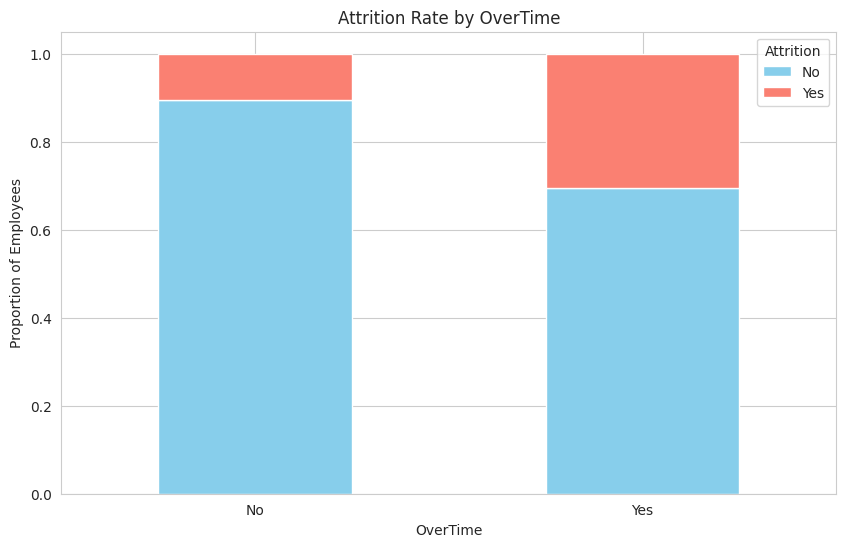

In [2]:
# Phase 2: Exploratory Data Analysis (EDA) and Domain Knowledge
""" The goal is to understand the relationships between the features and the Attrition target."""

# Bivariate Analysis: Feature vs. Attrition

# 1. Categorical Features
# Create a cross-tabulation to see counts and then normalize to see percentages
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Attrition Rate by OverTime')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

In [3]:
""" 
Analyzing Each Bar

Bar 1: Employees Who Do NOT Work Overtime ("No")

    Look at the chart: This bar is almost entirely blue. The red section at the top is very small.
    Look at the numbers: The table shows for the "No" OverTime row:
        89.6% stayed (Attrition No: 0.895636).
        10.4% left (Attrition Yes: 0.104364).
    Conclusion: The attrition rate for employees not working overtime is very low.
    
Bar 2: Employees Who DO Work Overtime ("Yes")

    Look at the chart: This bar has a very large red section. It's much bigger than the red section in the first bar.
    Look at the numbers: The table shows for the "Yes" OverTime row:
        69.5% stayed (Attrition No: 0.694712).
        30.5% left (Attrition Yes: 0.305288).
    Conclusion: The attrition rate for employees working overtime is much, much higher.

This means that the attrition rate is nearly three times higher for employees who work overtime.
This is a very strong signal and tells you that OverTime is an extremely important feature to include in ml model to predict who will leave.
It's a major factor in employee burnout and turnover.
"""

' \nAnalyzing Each Bar\n\nBar 1: Employees Who Do NOT Work Overtime ("No")\n\n    Look at the chart: This bar is almost entirely blue. The red section at the top is very small.\n    Look at the numbers: The table shows for the "No" OverTime row:\n        89.6% stayed (Attrition No: 0.895636).\n        10.4% left (Attrition Yes: 0.104364).\n    Conclusion: The attrition rate for employees not working overtime is very low.\n    \nBar 2: Employees Who DO Work Overtime ("Yes")\n\n    Look at the chart: This bar has a very large red section. It\'s much bigger than the red section in the first bar.\n    Look at the numbers: The table shows for the "Yes" OverTime row:\n        69.5% stayed (Attrition No: 0.694712).\n        30.5% left (Attrition Yes: 0.305288).\n    Conclusion: The attrition rate for employees working overtime is much, much higher.\n\nThis means that the attrition rate is nearly three times higher for employees who work overtime.\nThis is a very strong signal and tells you th

Attrition                No       Yes
BusinessTravel                       
Non-Travel         0.920000  0.080000
Travel_Frequently  0.750903  0.249097
Travel_Rarely      0.850431  0.149569


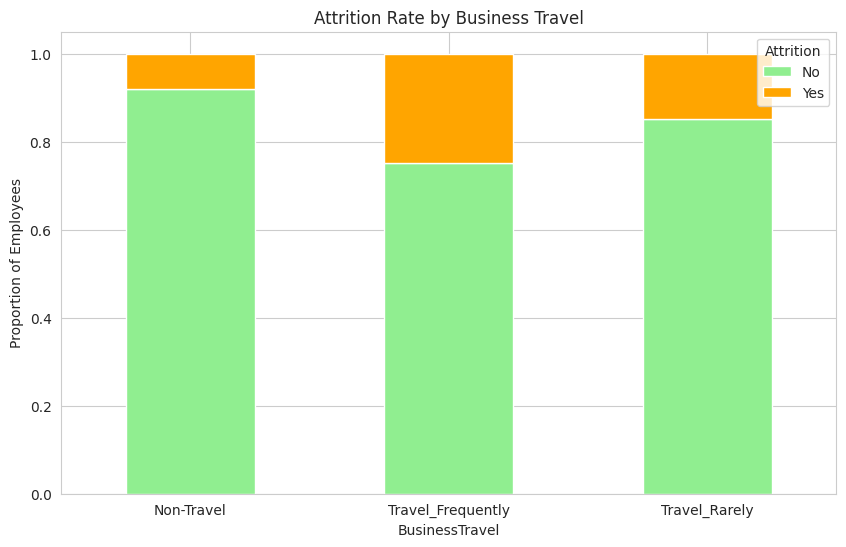

In [4]:
overtime_attrition = pd.crosstab(df['BusinessTravel'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['lightgreen', 'orange'])
plt.title('Attrition Rate by Business Travel')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

Attrition                     No       Yes
Department                                
Human Resources         0.809524  0.190476
Research & Development  0.861602  0.138398
Sales                   0.793722  0.206278


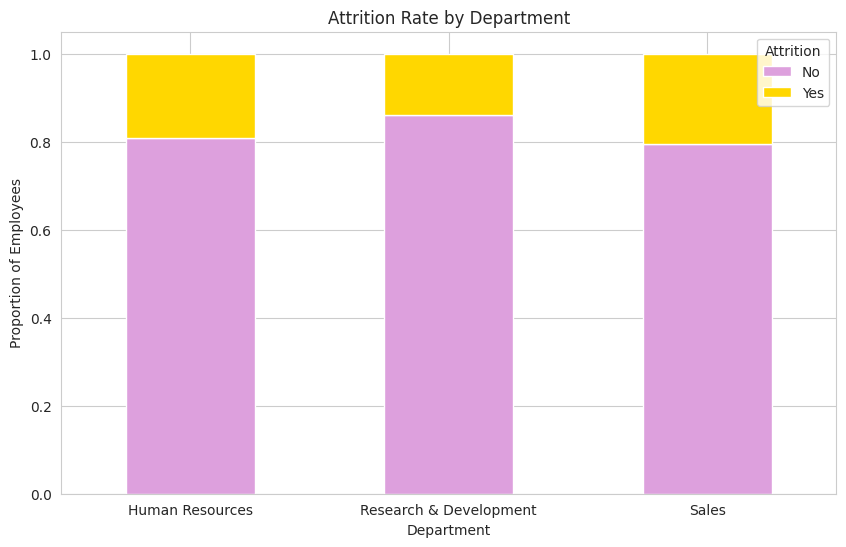

In [5]:
overtime_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['plum', 'gold'])
plt.title('Attrition Rate by Department')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

Attrition            No       Yes
MaritalStatus                    
Divorced       0.899083  0.100917
Married        0.875186  0.124814
Single         0.744681  0.255319


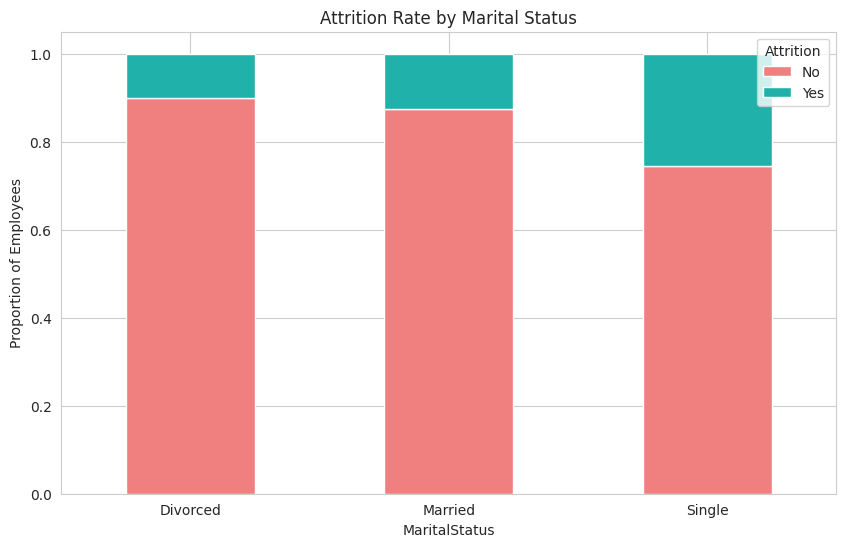

In [6]:
overtime_attrition = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['lightcoral', 'lightseagreen'])
plt.title('Attrition Rate by Marital Status')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

Attrition        No       Yes
Gender                       
Female     0.852041  0.147959
Male       0.829932  0.170068


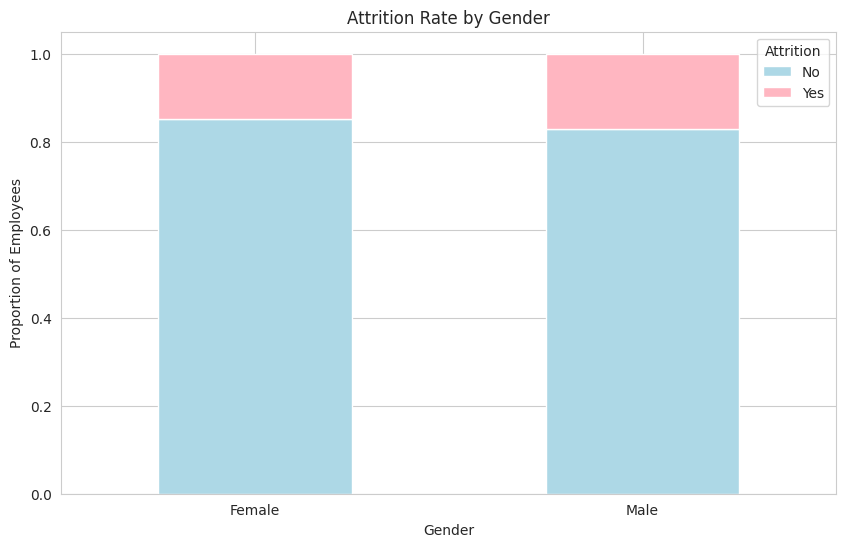

In [7]:
overtime_attrition = pd.crosstab(df['Gender'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['lightblue', 'lightpink'])
plt.title('Attrition Rate by Gender')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

In [ ]:
""" 
Detailed Analysis (Ranked from Most Important to Least Important)

1. MaritalStatus (Keep - Very Strong Predictor)

    Single: Attrition rate is 25.5%
    Married: Attrition rate is 12.5%
    Divorced: Attrition rate is 10.1%
    
Analysis: This is a very powerful feature. The attrition rate for single employees is more than double that of married or divorced employees. 
This large variation provides a strong signal for a machine learning model to learn from. Definitely keep this column.

2. BusinessTravel (Keep - Strong Predictor)

    Travel_Frequently: Attrition rate is 24.9%
    Travel_Rarely: Attrition rate is 15.0%
    Non-Travel: Attrition rate is 8.0%
    
Analysis: This feature also shows a very clear and strong trend. 
Employees who travel frequently have an attrition rate that is more than three times higher than those who don't travel at all. 
This is a significant difference that the model can easily use. Definitely keep this column.

3. Department (Keep - Good Predictor)

    Sales: Attrition rate is 20.6%
    Human Resources: Attrition rate is 19.0%
    Research & Development: Attrition rate is 13.8%
    
Analysis: There is a noticeable difference here. The attrition rate in the Sales department is significantly higher (almost 7 percentage points more) than in the Research & Development department. 
This suggests that the department an employee works in has a meaningful impact on their likelihood to leave. You should keep this column.

4. Gender (Consider Removing - Weak Predictor)

    Male: Attrition rate is 17.0%
    Female: Attrition rate is 14.8%
    
Analysis: While there is a difference, it is very small. 
The attrition rate for males is only about 2.2 percentage points higher than for females. 
Compared to the massive differences seen in MaritalStatus and BusinessTravel, this feature provides very little information to help the model distinguish between someone who will leave and someone who will stay.

Final Recommendation

    Keep: MaritalStatus, BusinessTravel, and Department. They all show significant variations in attrition rates across their categories.
    
    Remove: Gender is the weakest feature by far and the prime candidate for removal. Including it is unlikely to improve your model's performance and may just add unnecessary complexity.
"""

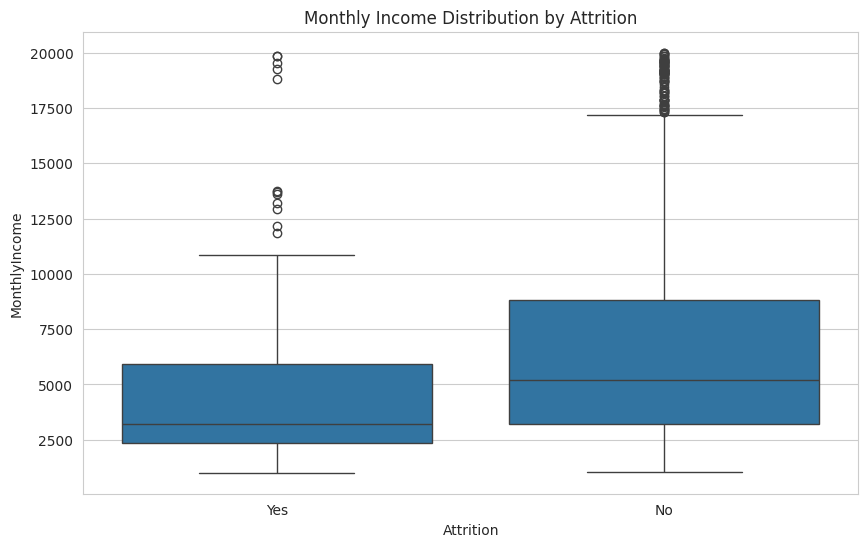

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64


In [8]:
# 2. Numerical Features

# Create a boxplot to compare distributions
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income Distribution by Attrition')
plt.show()

# You can also loot at the median values
print(df.groupby('Attrition')['MonthlyIncome'].median())


In [ ]:
""" 
The Line Inside the Box (Median):
    This represents the 50th percentile. Exactly half of the employees in that group earn more than this value, and half earn less.
    Your Data Shows: The median monthly income for employees who left (Yes) is $3,202.
    Your Data Shows: The median monthly income for employees who stayed (No) is $5,204.
    Immediate Insight: Right away, you see that the typical employee who leaves earns significantly less than the typical employee who stays.
"""

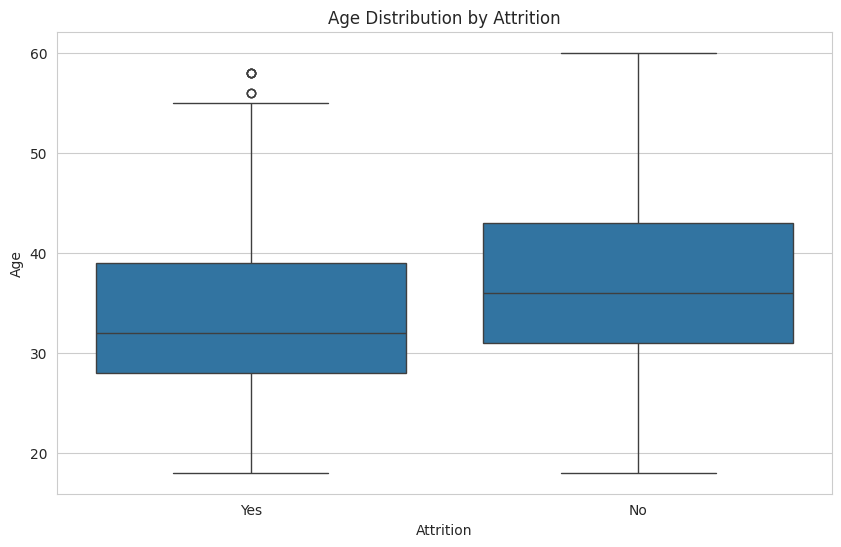

Attrition
No     36.0
Yes    32.0
Name: Age, dtype: float64


In [9]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age Distribution by Attrition')
plt.show()

# You can also loot at the median values
print(df.groupby('Attrition')['Age'].median())

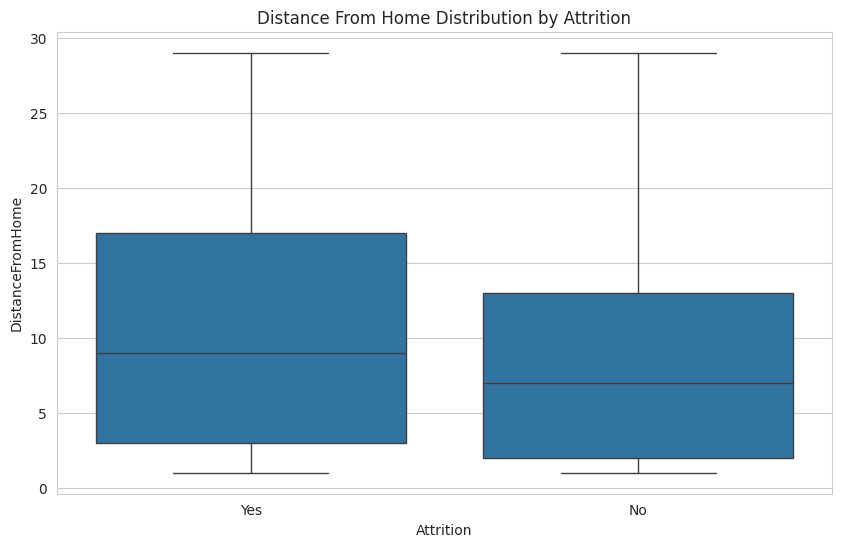

Attrition
No     7.0
Yes    9.0
Name: DistanceFromHome, dtype: float64


In [10]:
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title('Distance From Home Distribution by Attrition')
plt.show()

# You can also loot at the median values
print(df.groupby('Attrition')['DistanceFromHome'].median())

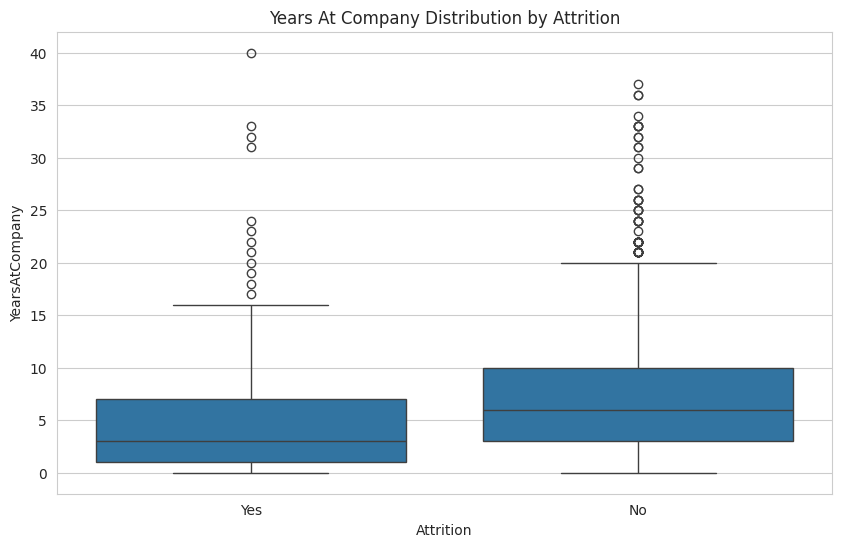

Attrition
No     6.0
Yes    3.0
Name: YearsAtCompany, dtype: float64


In [11]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years At Company Distribution by Attrition')
plt.show()

# You can also loot at the median values
print(df.groupby('Attrition')['YearsAtCompany'].median())

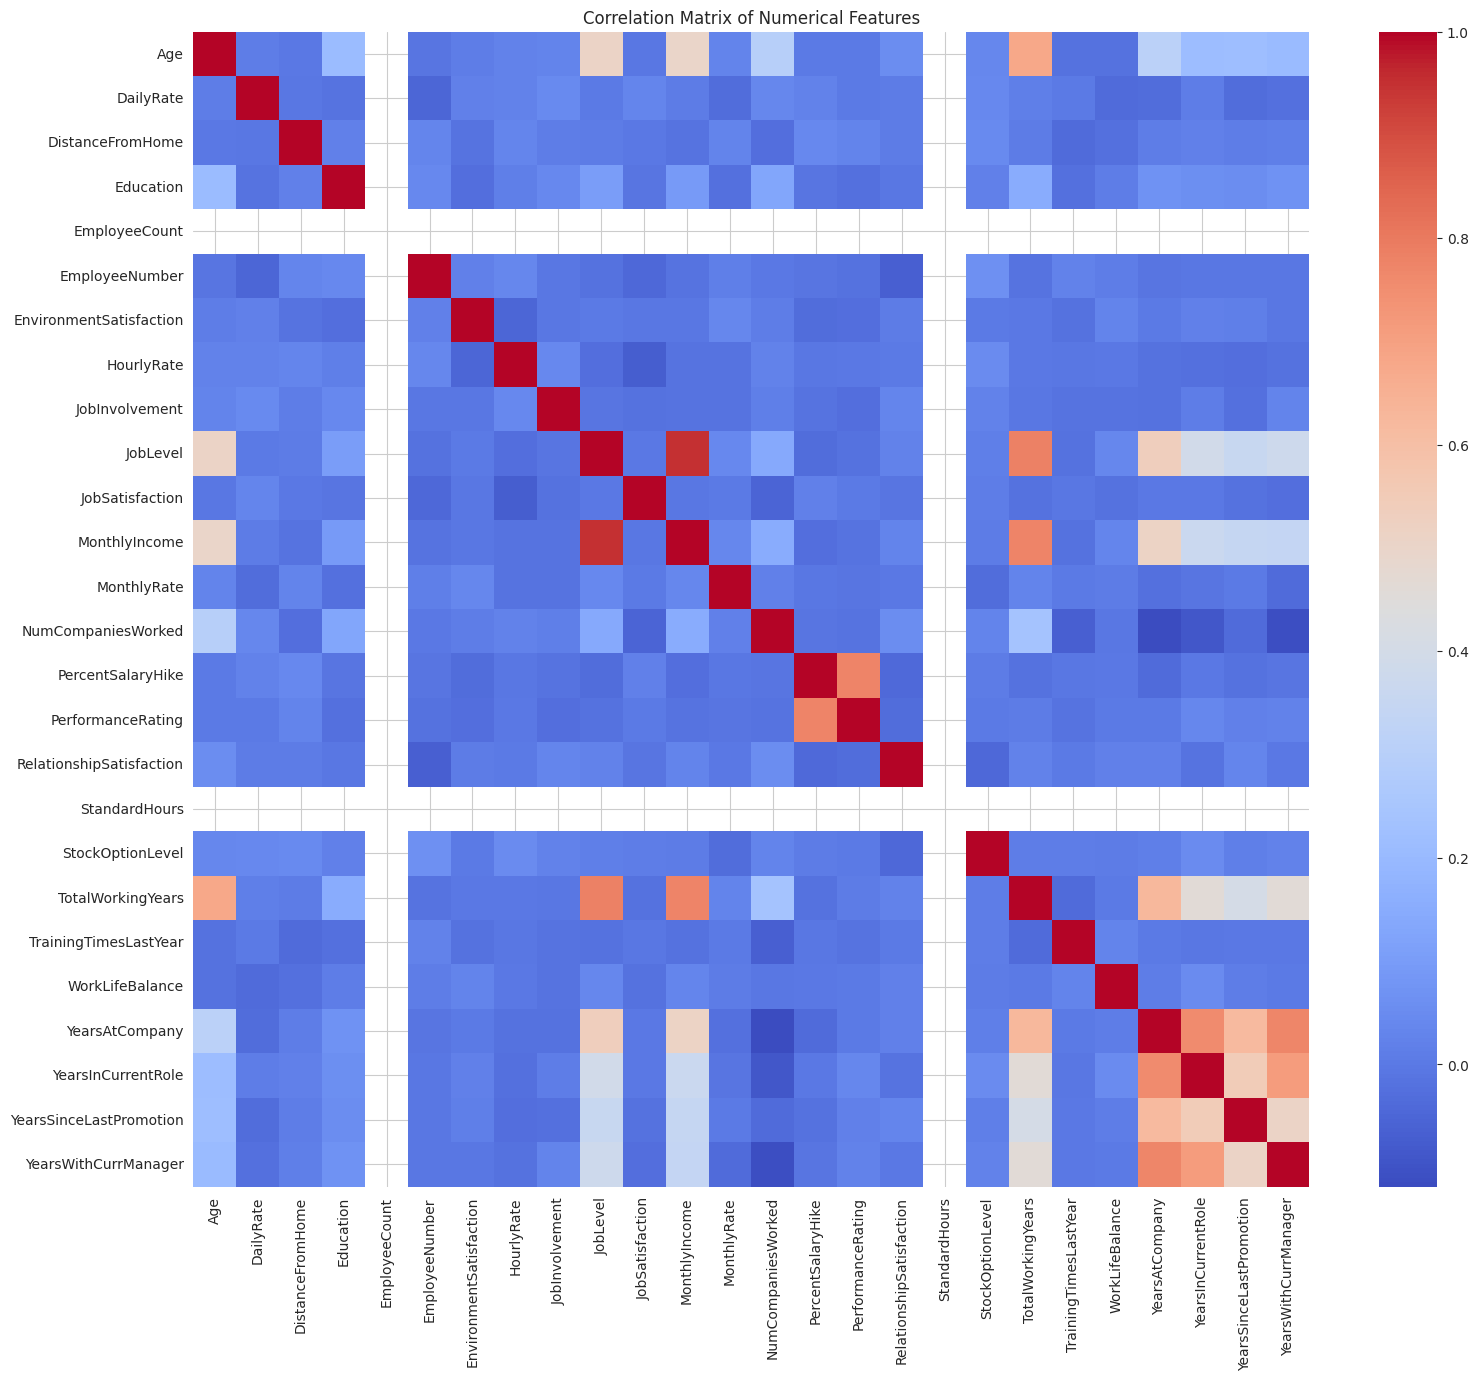

DailyRate             DailyRate               1.000000
JobLevel              MonthlyIncome           0.950300
                      TotalWorkingYears       0.782208
PerformanceRating     PercentSalaryHike       0.773550
MonthlyIncome         TotalWorkingYears       0.772893
YearsWithCurrManager  YearsAtCompany          0.769212
YearsAtCompany        YearsInCurrentRole      0.758754
YearsInCurrentRole    YearsWithCurrManager    0.714365
dtype: float64


In [12]:
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# To find highly correlated pairs easily:
# Unstack the matrix to get a list of pairs
high_corr = corr_matrix.abs().unstack()
# Sort and remove self-correlations and duplicates
high_corr = high_corr.sort_values(ascending=False).drop_duplicates()
print(high_corr[high_corr > 0.7].head(10))  # Show top 10 correlated pairs excluding self-correlation

Attrition                No       Yes
PerformanceRating                    
3                  0.839228  0.160772
4                  0.836283  0.163717


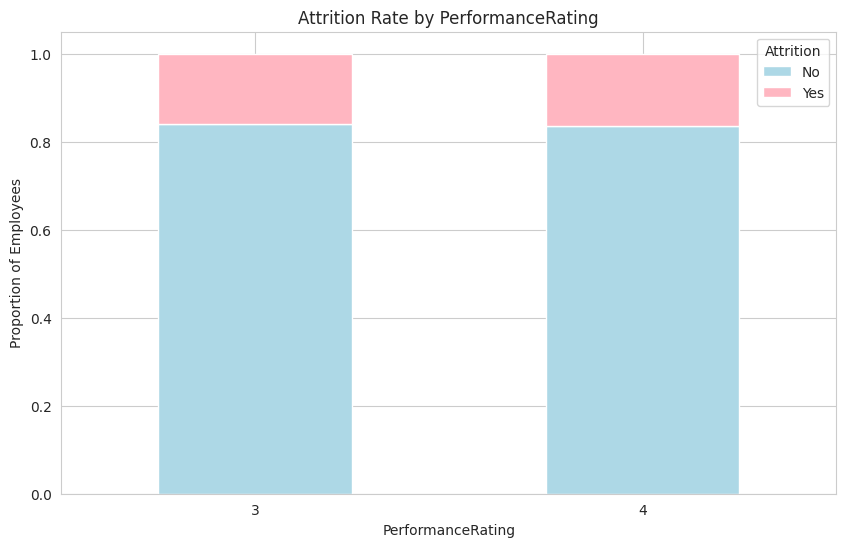

In [19]:
overtime_attrition = pd.crosstab(df['PerformanceRating'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Visualize it
overtime_attrition.plot(kind='bar', stacked=True, color=['lightblue', 'lightpink'])
plt.title('Attrition Rate by PerformanceRating')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.show()

In [ ]:

""" 
so this analysis shows that in catedorical features, Gender will be removed and 
in numerical features, Joblevel gonna be removed and also YearsAtCompany might be removed.


'PerformanceRating' has 2 unique values those are 3 and 4. 'PerformanceRating' is an ordinal feature.
but the analysis shows that it has very less impact on Attrition, so it can be removed as well.
"""